In [1]:
import pandas_datareader as pd_data
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import math as m
import scipy as sp
import datetime


In [2]:
start = datetime.datetime(2012, 1, 1) #(2000, 1, 1)
end = datetime.datetime(2015, 5, 31) #(2020, 5, 31)

USyields = pd_data.DataReader(['DGS1','DGS5','DGS10','DGS20','DGS30'], 'fred', start, end)


In [3]:
USyields.head()

,DGS1,DGS5,DGS10,DGS20,DGS30
DATE,,,,,
2012-01-02,NaN,NaN,NaN,NaN,NaN
2012-01-03,0.12,0.89,1.97,2.67,2.98
2012-01-04,0.12,0.89,2.00,2.71,3.03
2012-01-05,0.11,0.88,2.02,2.74,3.06
2012-01-06,0.12,0.86,1.98,2.70,3.02


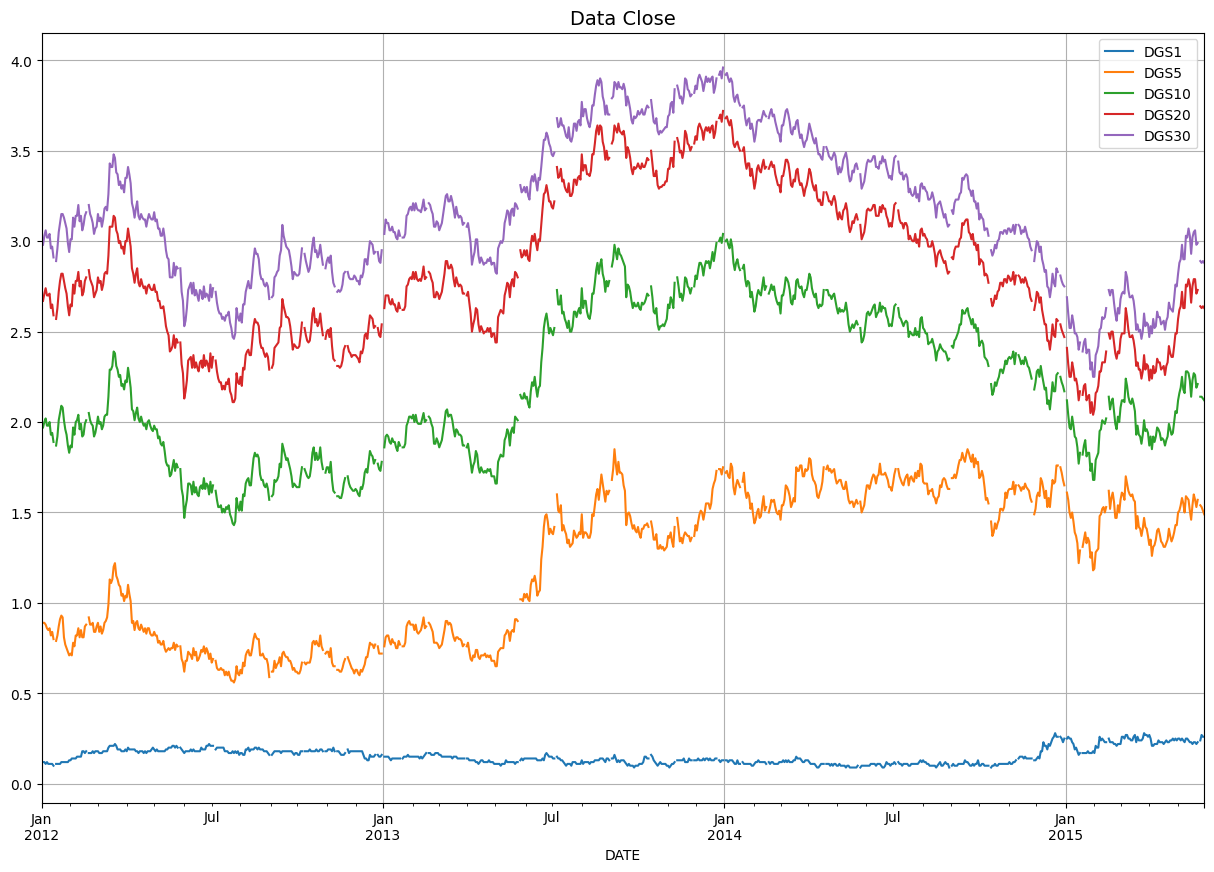

In [4]:
USyields.plot(figsize = (15, 10), grid = True)
plt.title('Data Close', fontsize=14)
plt.show()

In [5]:
USYieldsRtn = USyields.diff().dropna()
USYieldsRtn.head()

,DGS1,DGS5,DGS10,DGS20,DGS30
DATE,,,,,
2012-01-04,0.00,0.00,0.03,0.04,0.05
2012-01-05,-0.01,-0.01,0.02,0.03,0.03
2012-01-06,0.01,-0.02,-0.04,-0.04,-0.04
2012-01-09,-0.01,-0.01,0.00,0.00,0.00
2012-01-10,0.00,0.01,0.02,0.01,0.02


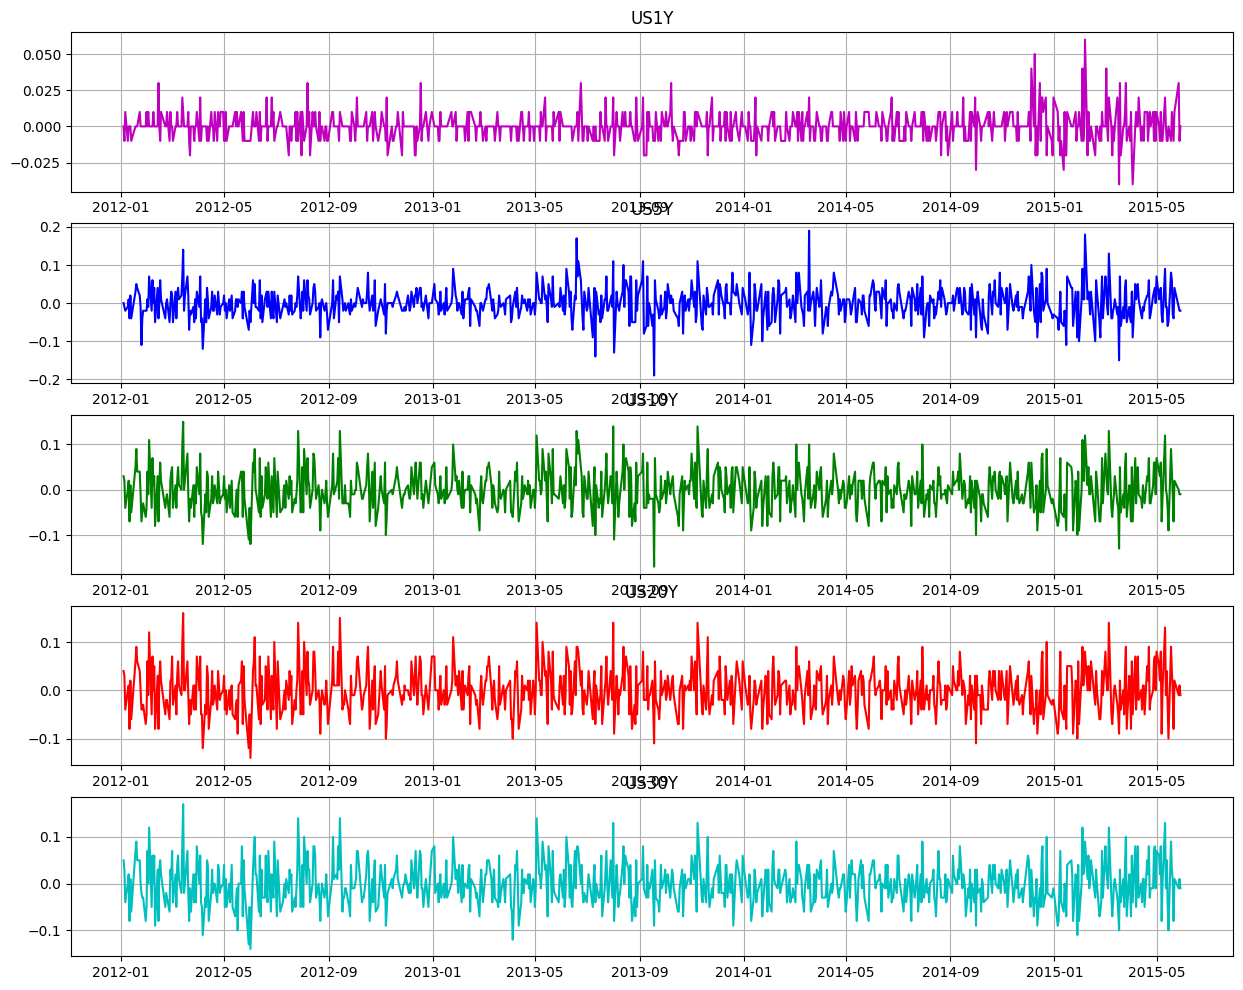

In [6]:
fig = plt.figure(figsize = (15,12))
ax1 = fig.add_subplot(5, 1, 1)
ax2 = fig.add_subplot(5, 1, 2)
ax3 = fig.add_subplot(5, 1, 3)
ax4 = fig.add_subplot(5, 1, 4)
ax5 = fig.add_subplot(5, 1, 5)

ax1.plot(USYieldsRtn['DGS1'], color ='m')
ax1.set_title('US1Y')
ax2.plot(USYieldsRtn['DGS5'], color = 'b')
ax2.set_title('US5Y')
ax3.plot(USYieldsRtn['DGS10'], color = 'g')
ax3.set_title('US10Y')
ax4.plot(USYieldsRtn['DGS20'], color = 'r')
ax4.set_title('US20Y')
ax5.plot(USYieldsRtn['DGS30'], color = 'c')
ax5.set_title('US30Y')

ax1.grid()
ax2.grid()
ax3.grid()
ax4.grid()
ax5.grid()


In [7]:
# Create a time series for 25 yield to show example.
np.random.seed(17)
std = USYieldsRtn['DGS5'].std()*0.4
rv = stats.norm(0,std)
n = len(USYieldsRtn['DGS1'])
z = rv.rvs(size = n)


USYieldsRtn['DGS25'] = USYieldsRtn['DGS5']*0.2 + USYieldsRtn['DGS20']*0.3 + USYieldsRtn['DGS30']*0.35+ z  

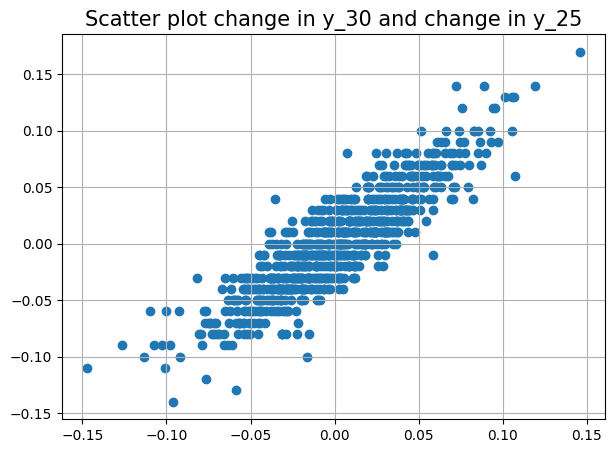

In [8]:
x = USYieldsRtn['DGS25']
y = USYieldsRtn['DGS30']

plt.figure(1, figsize=(7,5)) 
plt.scatter(x,y)
plt.title('Scatter plot change in y_30 and change in y_25', fontsize = 15)
plt.grid()
plt.savefig("OLS_Example1")

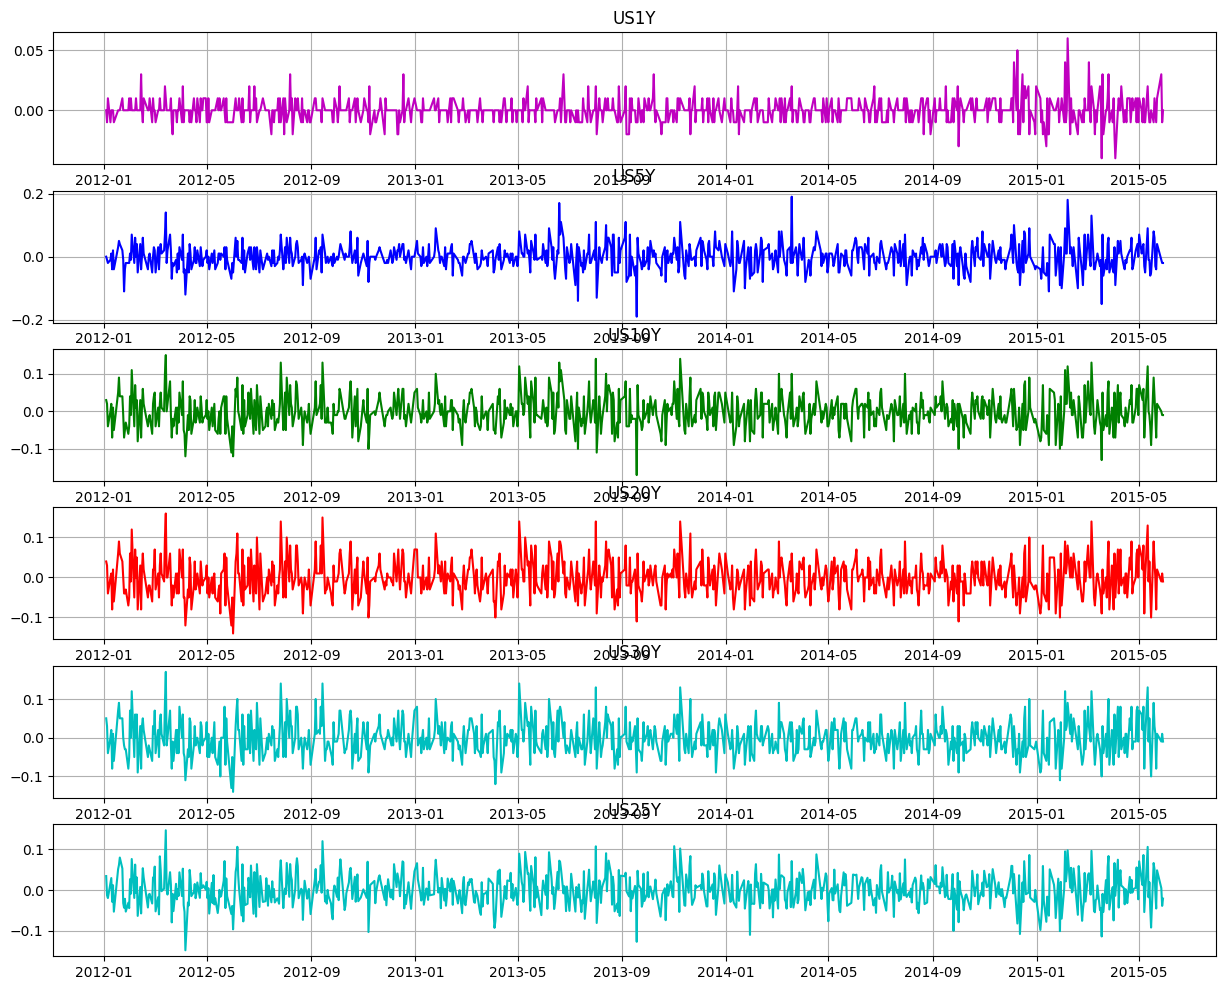

In [9]:
fig = plt.figure(figsize = (15,12))
ax1 = fig.add_subplot(6, 1, 1)
ax2 = fig.add_subplot(6, 1, 2)
ax3 = fig.add_subplot(6, 1, 3)
ax4 = fig.add_subplot(6, 1, 4)
ax5 = fig.add_subplot(6, 1, 5)
ax6 = fig.add_subplot(6, 1, 6)

ax1.plot(USYieldsRtn['DGS1'], color ='m')
ax1.set_title('US1Y')
ax2.plot(USYieldsRtn['DGS5'], color = 'b')
ax2.set_title('US5Y')
ax3.plot(USYieldsRtn['DGS10'], color = 'g')
ax3.set_title('US10Y')
ax4.plot(USYieldsRtn['DGS20'], color = 'r')
ax4.set_title('US20Y')
ax5.plot(USYieldsRtn['DGS30'], color = 'c')
ax5.set_title('US30Y')
ax6.plot(USYieldsRtn['DGS25'], color = 'c')
ax6.set_title('US25Y')

ax1.grid()
ax2.grid()
ax3.grid()
ax4.grid()
ax5.grid()
ax6.grid()


In [10]:
import statsmodels.api as sm

X = USYieldsRtn['DGS30']
y = USYieldsRtn['DGS25']

Xnew = sm.add_constant(X)
model_yield_2 = sm.OLS(y, Xnew).fit()
y_yield_2 = model_yield_2.predict(Xnew)
model_yield_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  DGS25   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     2838.
Date:                Sun, 02 Oct 2022   Prob (F-statistic):          1.46e-267
Time:                        11:50:15   Log-Likelihood:                 2088.2
No. Observations:                 816   AIC:                            -4172.
Df Residuals:                     814   BIC:                            -4163.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.001      0.600      0.548      -0.001       0.002
DGS30          0.7757      0.015     53.275      0.000       0.747       0.804
==============================================================================
Omnibus:                        7.694   Durbin-Watson:                   2.101
Prob(Omnibus):                  0.021   Jarque-Bera (JB):                8.580
Skew:                          -0.157   Prob(JB):                       0.0137
Kurtosis:                       3.392   Cond. No.                         22.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

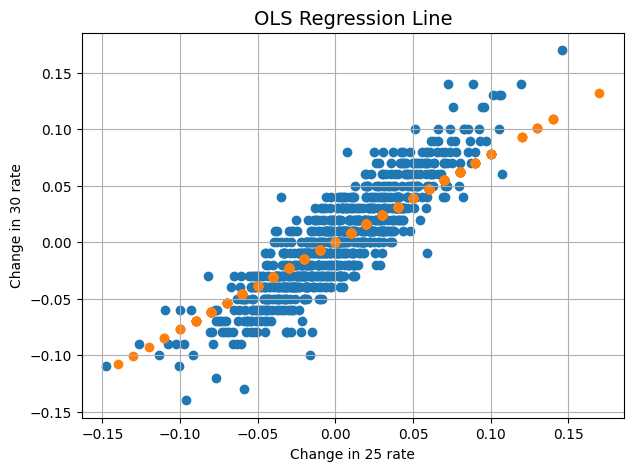

In [11]:
x = USYieldsRtn['DGS25']
y = USYieldsRtn['DGS30']
y_fitted = model_yield_2.predict(Xnew)
plt.figure(1, figsize=(7,5)) 
plt.scatter(x,y)
plt.scatter(X,y_fitted)
plt.title('OLS Regression Line', size = 14)
plt.xlabel('Change in 25 rate')
plt.ylabel('Change in 30 rate')
plt.grid()
plt.savefig("OLS_yield25")

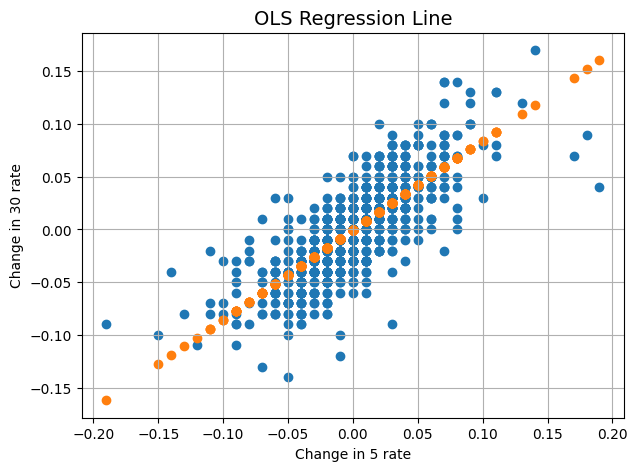

In [12]:
X= USYieldsRtn['DGS5']
y = USYieldsRtn['DGS30']
Xnew = sm.add_constant(X)
model_yield_3 = sm.OLS(y, Xnew).fit()
y_fitted = model_yield_3.predict(Xnew)
plt.figure(1, figsize=(7,5)) 
plt.scatter(X,y)
plt.scatter(X,y_fitted)
plt.title('OLS Regression Line', size = 14)
plt.xlabel('Change in 5 rate')
plt.ylabel('Change in 30 rate')
plt.grid()

In [13]:
start_date = '2012-01-01'
end_date = '2019-08-14'


df1 = pd_data.DataReader('spy','yahoo',start_date,end_date)

spy_rtn = np.log(df1['Adj Close']).diff().dropna()

df2 = pd_data.DataReader('VIXY','yahoo',start_date,end_date)

vix_rtn = np.log(df2['Adj Close']).diff().dropna()
vix_rtn

Date
2012-01-04   -0.019850
2012-01-05   -0.022576
2012-01-06   -0.015241
2012-01-09   -0.015476
2012-01-10   -0.020301
                ...   
2019-08-08   -0.062194
2019-08-09    0.036786
2019-08-12    0.070166
2019-08-13   -0.077871
2019-08-14    0.131140
Name: Adj Close, Length: 1915, dtype: float64

In [14]:
spy_rtn

Date
2012-01-04    0.001567
2012-01-05    0.002659
2012-01-06   -0.002581
2012-01-09    0.002424
2012-01-10    0.008633
                ...   
2019-08-08    0.019430
2019-08-09   -0.006835
2019-08-12   -0.012248
2019-08-13    0.015432
2019-08-14   -0.030013
Name: Adj Close, Length: 1915, dtype: float64

In [15]:
vix_rtn

Date
2012-01-04   -0.019850
2012-01-05   -0.022576
2012-01-06   -0.015241
2012-01-09   -0.015476
2012-01-10   -0.020301
                ...   
2019-08-08   -0.062194
2019-08-09    0.036786
2019-08-12    0.070166
2019-08-13   -0.077871
2019-08-14    0.131140
Name: Adj Close, Length: 1915, dtype: float64